## Categorising countries

### Data Source

The data used in this task was originally sourced from Help.NGO. This international non-governmental organisation specialises in emergency response, preparedness, and risk mitigation.

### Dataset Attributes
- **country**: name of the country
- **child_mort**: death of children under 5 years of age per 1000 live births
- **exports**: exports of goods and services per capita. Given as a percentage of the GDP per capita
- **health**: total health spending per capita. Given as a percentage of GDP per capita
- **imports**: imports of goods and services per capita. Given as a percentage of the GDP per capita
- **income**: net income per person
- **inflation**: the measurement of the annual growth rate of the Total GDP
- **life_expec**: the average number of years a new born child would live if the current mortality patterns remain the same
- **total_fer**: the number of children that would be born to each woman if the current age-fertility rates remains the same
- **gdpp**: the GDP per capita. Calculated as the Total GDP divided by the total population.

## Objective
To group countries using socio-economic and health factors to determine the development status of the country.

In [1]:
# Import libraries
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Random state seed for reproducibility
rseed = 42

# Setting the styling of the Seaborn figure
sns.set_style('darkgrid')

## Load and explore data

In [3]:
# Import the dataset
# The Country-data.csv file should be in the same directory as this notebook
df = pd.read_csv('Country-data.csv')

In [4]:
# Check the shape of the dataset
print("Dataset shape:", df.shape)

Dataset shape: (167, 10)


In [5]:
# Check datatypes & counts
print("\nData types and non-null counts:")
print(df.info())


Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB
None


In [6]:
# Get descriptive statistics for all numeric columns
print("\nDescriptive statistics:")
print(df.describe())


Descriptive statistics:
       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.810000    0.065900     609.000000   
25%      8.250000   23.800000    4.920000   30.200000    3355.000000   
50%     19.300000   35.000000    6.320000   43.300000    9960.000000   
75%     62.100000   51.350000    8.600000   58.750000   22800.000000   
max    208.000000  200.000000   17.900000  174.000000  125000.000000   

        inflation  life_expec   total_fer           gdpp  
count  167.000000  167.000000  167.000000     167.000000  
mean     7.781832   70.555689    2.947964   12964.155689  
std     10.570704    8.893172    1.513848   18328.704809  
min     -4.210000   32.100000    1.150000     231.000000  
25%      1.810000   65.300000  

In [7]:
# Identify any missing data
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## Preprocessing and Feature Selection

In [8]:
# Drop any non-numeric features (columns)
# The 'country' column is a string identifier and not useful for clustering algorithms
df_numeric = df.drop('country', axis=1)

print(f"Shape after dropping non-numeric columns: {df_numeric.shape}")
print(f"Remaining columns: {list(df_numeric.columns)}")

Shape after dropping non-numeric columns: (167, 9)
Remaining columns: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


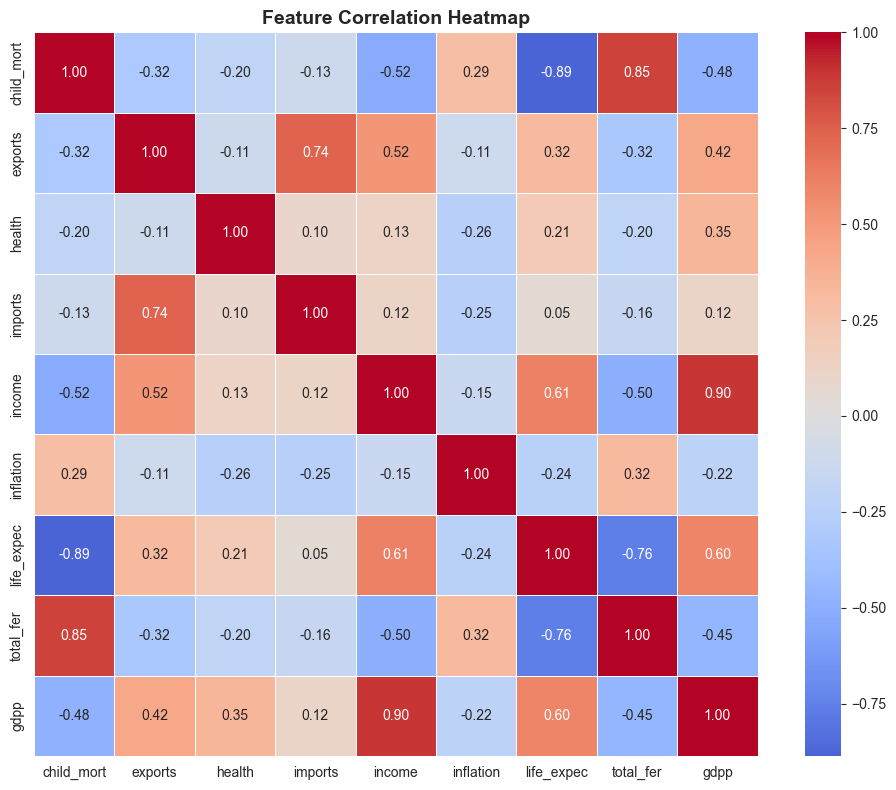

In [9]:
# Create a correlation map of features to explore relationships between features
plt.figure(figsize=(10, 8))
corr = df_numeric.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

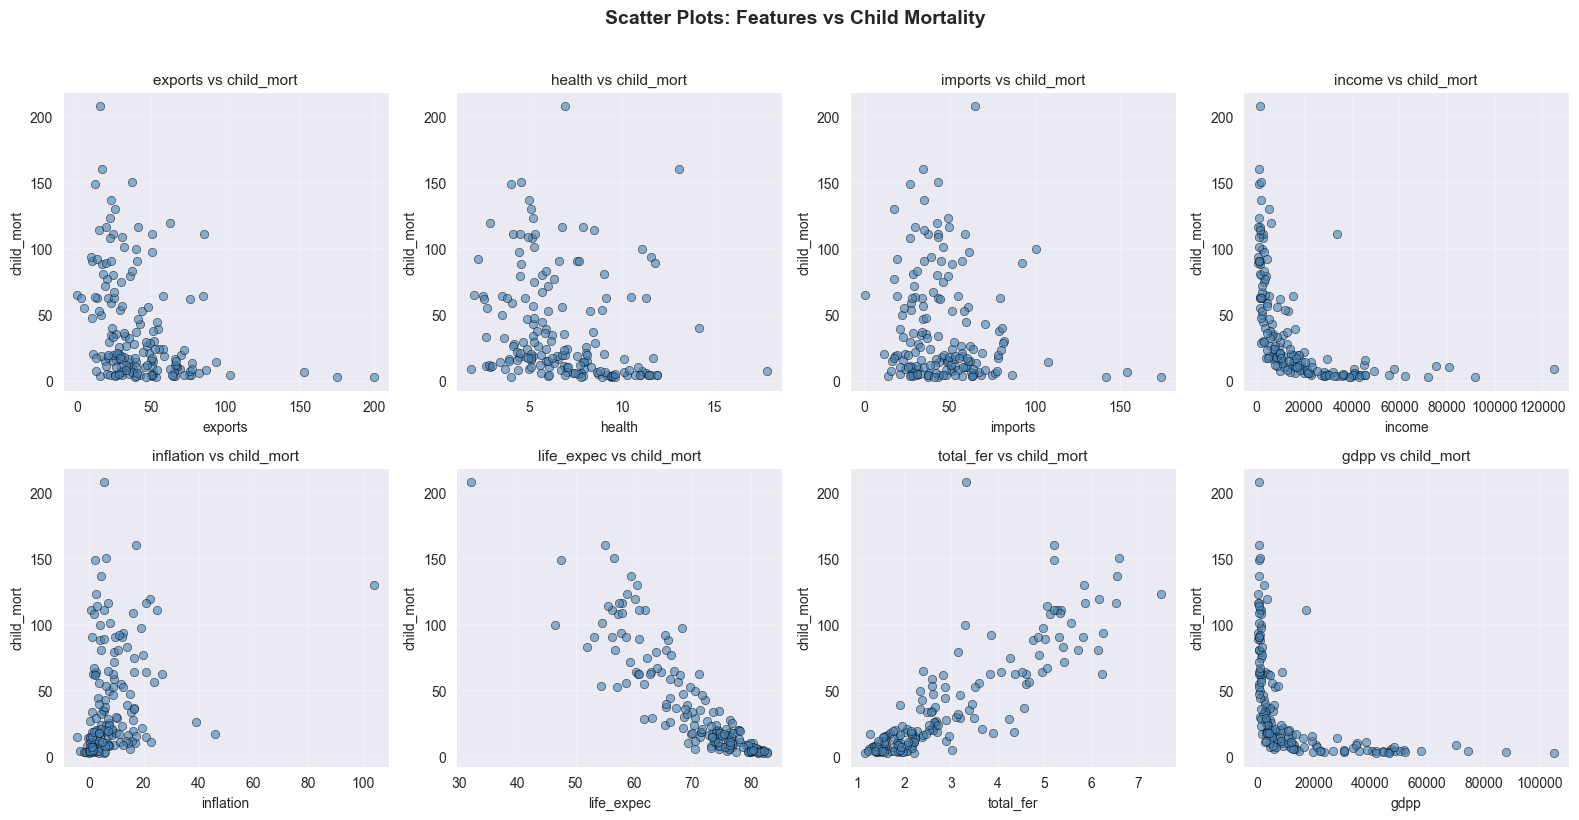

In [10]:
# Explore the continuous independent features against child_mort using scatter plots.
# These plots help identify which features show clear patterns with child mortality.
features_vs_child_mort = ['exports', 'health', 'imports', 'income',
                          'inflation', 'life_expec', 'total_fer', 'gdpp']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, feat in enumerate(features_vs_child_mort):
    axes[i].scatter(df_numeric[feat], df_numeric['child_mort'],
                    alpha=0.6, edgecolors='black', linewidth=0.5, color='steelblue')
    axes[i].set_xlabel(feat, fontsize=10)
    axes[i].set_ylabel('child_mort', fontsize=10)
    axes[i].set_title(f'{feat} vs child_mort', fontsize=11)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Scatter Plots: Features vs Child Mortality', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

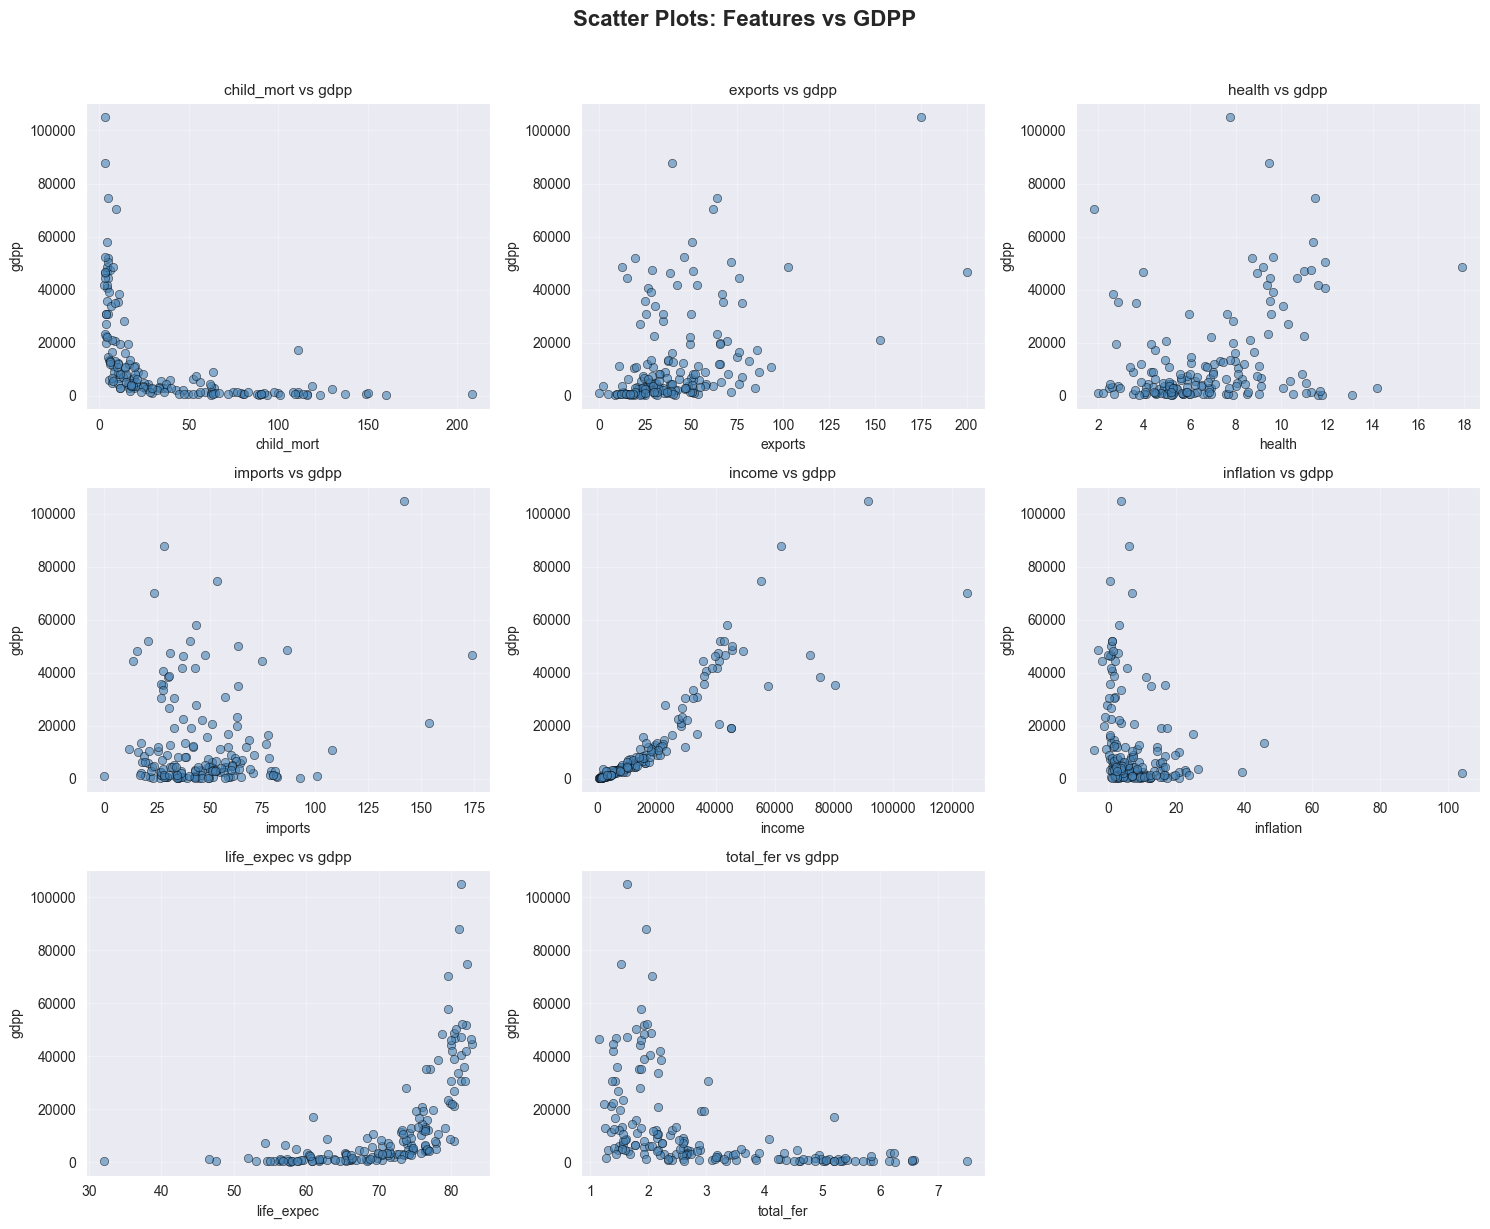

In [11]:
# Explore the continuous independent features against gdpp using scatter plots.
# This helps identify which feature combinations are most promising for clustering.
features_vs_gdpp = ['child_mort', 'exports', 'health', 'imports',
                    'income', 'inflation', 'life_expec', 'total_fer']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, feat in enumerate(features_vs_gdpp):
    axes[i].scatter(df_numeric[feat], df_numeric['gdpp'],
                    alpha=0.6, edgecolors='black', linewidth=0.5, color='steelblue')
    axes[i].set_xlabel(feat, fontsize=10)
    axes[i].set_ylabel('gdpp', fontsize=10)
    axes[i].set_title(f'{feat} vs gdpp', fontsize=11)
    axes[i].grid(True, alpha=0.3)

# Hide the unused 9th subplot
axes[8].axis('off')

plt.suptitle('Scatter Plots: Features vs GDPP', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Observation: Most Promising Plots for Clustering

Based on the scatter plots above, the following combinations appear most promising
for separating countries into distinct clusters:

1. **child_mort vs gdpp**: Shows a strong inverse relationship with clear grouping.
   High child mortality aligns with low GDPP, and vice versa.
2. **income vs gdpp**: Very strong positive correlation with tight clustering.
3. **life_expec vs gdpp**: Clear positive trend with distinct separation.
4. **total_fer vs gdpp**: Strong inverse relationship suggesting demographic divides.

The **child_mort vs gdpp** plot is particularly promising as it captures the
core development divide: wealthy countries have low child mortality, while
poor countries suffer high child mortality.

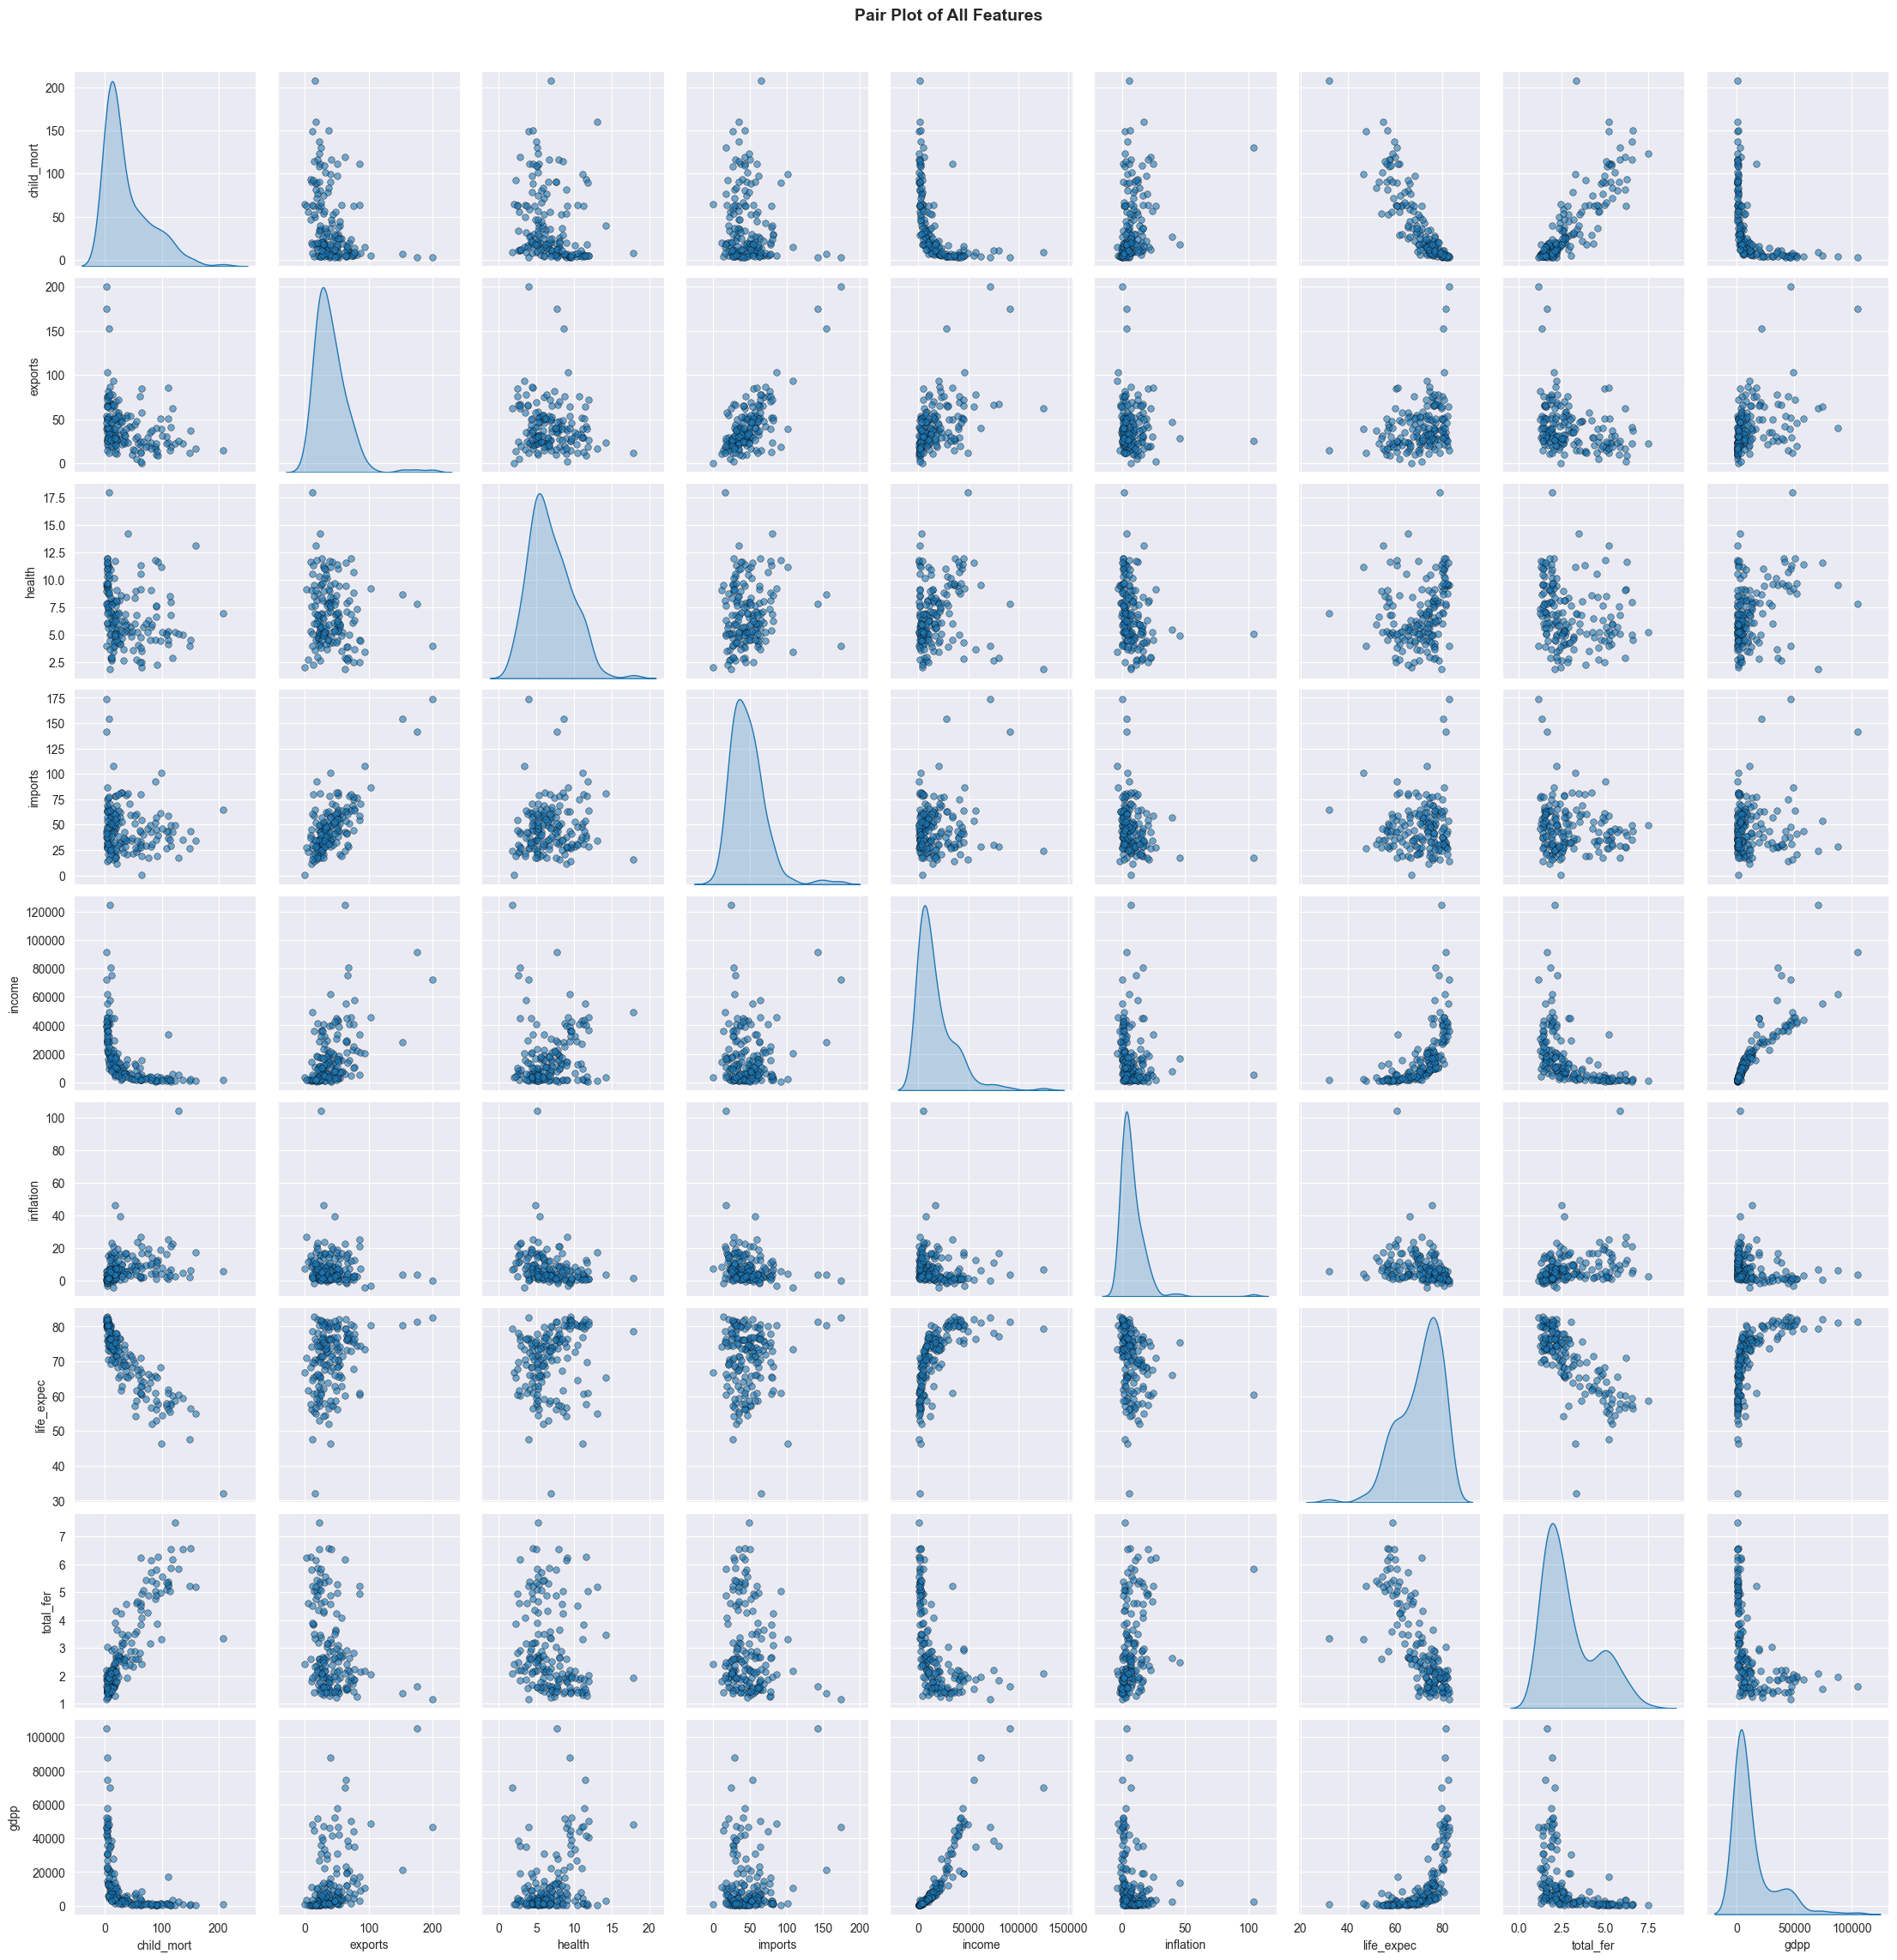

In [12]:
# Create a pair plot
# The pair plot shows all pairwise relationships and univariate distributions on the diagonal
sns.pairplot(df_numeric, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'})
plt.suptitle('Pair Plot of All Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

Creating a pair plot is a helpful step in exploring the relationships between features before clustering data. The diagonal plots within a pair plot show the distribution of individual features, which can give insight into how the data is spread for each feature. While distinct peaks in these plots may hint at features with distinct ranges, true separability is better assessed by examining the off-diagonal plots, which show the relationships between pairs of features. These relationships provide a clearer view of how well the data might separate into clusters.

### Scaling the Data

In [13]:
# Normalise the data using MinMaxScaler
# Scaling is essential for K-Means because it uses Euclidean distance, which is
# sensitive to feature magnitude. Without scaling, high-range features like income
# and gdpp would dominate the clustering.
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_numeric),
    columns=df_numeric.columns,
    index=df_numeric.index
)

print("First 5 rows of scaled data:")
print(df_scaled.head())
print(f"\nScaled data range: [{df_scaled.min().min():.4f}, {df_scaled.max().max():.4f}]")

First 5 rows of scaled data:
   child_mort   exports    health   imports    income  inflation  life_expec  \
0    0.426485  0.049482  0.358608  0.257765  0.008047   0.126144    0.475345   
1    0.068160  0.139531  0.294593  0.279037  0.074933   0.080399    0.871795   
2    0.120253  0.191559  0.146675  0.180149  0.098809   0.187691    0.875740   
3    0.566699  0.311125  0.064636  0.246266  0.042535   0.245911    0.552268   
4    0.037488  0.227079  0.262275  0.338255  0.148652   0.052213    0.881657   

   total_fer      gdpp  
0   0.736593  0.003073  
1   0.078864  0.036833  
2   0.274448  0.040365  
3   0.790221  0.031488  
4   0.154574  0.114242  

Scaled data range: [0.0000, 1.0000]


## K-Means Clustering

### Selecting K

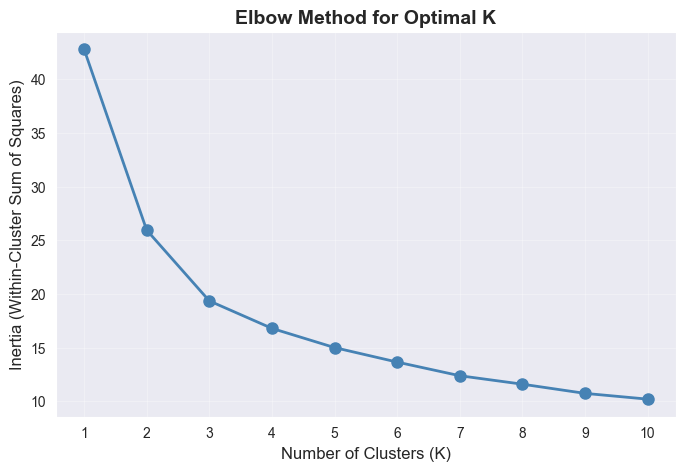

In [14]:
def eval_Kmeans(x, k, r):
    """
    Evaluates the KMeans clustering for a given number of clusters (k)
    and random seed (r), returning the inertia (sum of squared distances
    of samples to their closest cluster center).

    Parameters:
    - x: Data to be clustered.
    - k: Number of clusters.
    - r: Random state for reproducibility.

    Returns:
    - inertia: Sum of squared distances within clusters.
    """
    kmeans = KMeans(n_clusters=k, random_state=r, max_iter=500, n_init=10)
    kmeans.fit(x)
    return kmeans.inertia_

def elbow_Kmeans(x, max_k=10, r=42):
    """
    Plots the inertia (within-cluster variance) against the number of
    clusters to help determine the optimal number of clusters (the 'elbow' point).

    Parameters:
    - x: Data to be clustered.
    - max_k: Maximum number of clusters to evaluate (default is 10).
    - r: Random state for reproducibility (default is 42).
    """
    within_cluster_vars = [eval_Kmeans(x, k, r) for k in range(1, max_k+1)]
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k+1), within_cluster_vars, marker='o',
             color='steelblue', linewidth=2, markersize=8)
    plt.xlabel('Number of Clusters (K)', fontsize=12)
    plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
    plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
    plt.xticks(range(1, max_k+1))
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot elbow curve using scaled dataset
elbow_Kmeans(df_scaled, max_k=10, r=rseed)

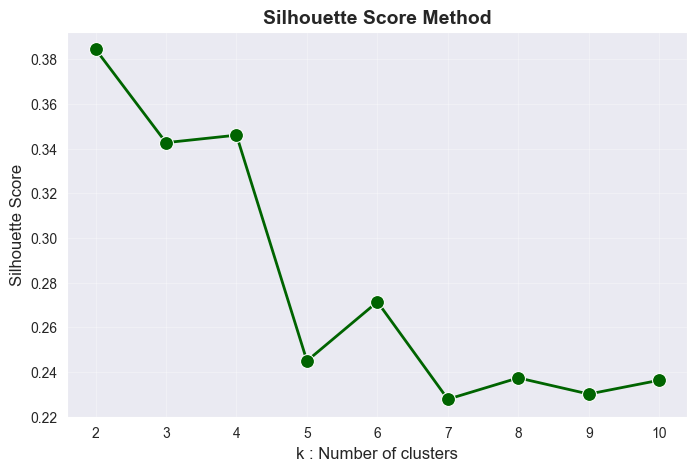

Silhouette scores by K:
  K=2: 0.3845
  K=3: 0.3427
  K=4: 0.3460
  K=5: 0.2449
  K=6: 0.2714
  K=7: 0.2278
  K=8: 0.2374
  K=9: 0.2301
  K=10: 0.2363


In [15]:
# Silhouette score method
# The silhouette score measures how similar an object is to its own cluster
# compared to other clusters. Range: [-1, 1], where higher is better.
kmax = 10
sil = []

for k in range(2, kmax+1):
    kmeans = KMeans(n_clusters=k, random_state=rseed, max_iter=500, n_init=10)
    kmeans.fit(df_scaled)
    labels = kmeans.labels_
    sil.append(silhouette_score(df_scaled, labels, metric='euclidean'))

plt.figure(figsize=(8, 5))
sns.lineplot(x=range(2, kmax+1), y=sil, marker='o',
             color='darkgreen', linewidth=2, markersize=10)
plt.title('Silhouette Score Method', fontsize=14, fontweight='bold')
plt.xlabel('k : Number of clusters', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(range(2, kmax+1))
plt.grid(True, alpha=0.3)
plt.show()

print("Silhouette scores by K:")
for k, score in zip(range(2, kmax+1), sil):
    print(f"  K={k}: {score:.4f}")

### Choosing K

Based on the elbow and silhouette score methods:

- **Elbow Method**: The inertia curve shows a distinct bend (elbow) at K=2 or K=3,
  after which the rate of decrease slows considerably.
- **Silhouette Score**: K=2 yields the highest score, but K=3 also performs well
  and aligns with real-world development categories (developed, developing, least developed).

**Selected K = 3**: Three clusters provide meaningful separation that matches
established socio-economic classifications while maintaining a respectable silhouette score.

## Fitting a K-Means Model with the selected K value

In [16]:
# Fitting K-means model with K=3
# random_state is set to rseed (42) for reproducibility
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=rseed, max_iter=500, n_init=10)
kmeans.fit(df_scaled)

print(f"K-Means model fitted with K={optimal_k}")
print(f"Cluster centers shape: {kmeans.cluster_centers_.shape}")

K-Means model fitted with K=3
Cluster centers shape: (3, 9)


In [17]:
# Count the number of observations in each cluster
cluster_counts = pd.Series(kmeans.labels_).value_counts().sort_index()
print(f"\nNumber of observations in each cluster:")
print(cluster_counts)


Number of observations in each cluster:
0    34
1    46
2    87
Name: count, dtype: int64


In [18]:
# Check model performance with the silhouette coefficient
sil_score = silhouette_score(df_scaled, kmeans.labels_, metric='euclidean')
print(f"\nSilhouette Score for K={optimal_k}: {sil_score:.4f}")
print(f"Interpretation: A score of {sil_score:.4f} indicates {'reasonable' if sil_score > 0.25 else 'weak'} cluster separation.")


Silhouette Score for K=3: 0.3427
Interpretation: A score of 0.3427 indicates reasonable cluster separation.


## Predictions

In [19]:
# Add the predicted cluster label column to the original dataframe
df['cluster'] = kmeans.labels_

print("First 10 rows with cluster assignments:")
print(df[['country', 'child_mort', 'gdpp', 'inflation', 'cluster']].head(10))

First 10 rows with cluster assignments:
               country  child_mort   gdpp  inflation  cluster
0          Afghanistan        90.2    553      9.440        1
1              Albania        16.6   4090      4.490        2
2              Algeria        27.3   4460     16.100        2
3               Angola       119.0   3530     22.400        1
4  Antigua and Barbuda        10.3  12200      1.440        2
5            Argentina        14.5  10300     20.900        2
6              Armenia        18.1   3220      7.770        2
7            Australia         4.8  51900      1.160        0
8              Austria         4.3  46900      0.873        0
9           Azerbaijan        39.2   5840     13.800        2


## Visualisation of clusters

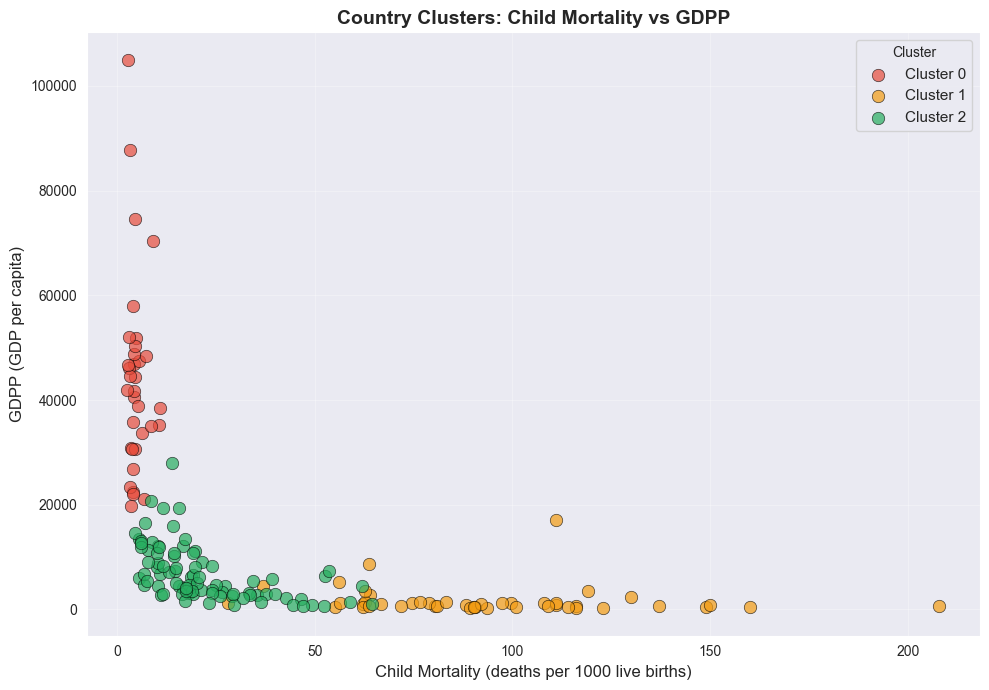

In [20]:
# Visualisation of clusters: child mortality vs gdpp
plt.figure(figsize=(10, 7))

# Define colors and labels for each cluster
cluster_colors = ['#e74c3c', '#f39c12', '#27ae60']  # Red, Orange, Green
cluster_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(optimal_k):
    cluster_data = df[df['cluster'] == i]
    plt.scatter(cluster_data['child_mort'], cluster_data['gdpp'],
                c=cluster_colors[i], label=cluster_labels[i],
                alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

plt.xlabel('Child Mortality (deaths per 1000 live births)', fontsize=12)
plt.ylabel('GDPP (GDP per capita)', fontsize=12)
plt.title('Country Clusters: Child Mortality vs GDPP', fontsize=14, fontweight='bold')
plt.legend(title='Cluster', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

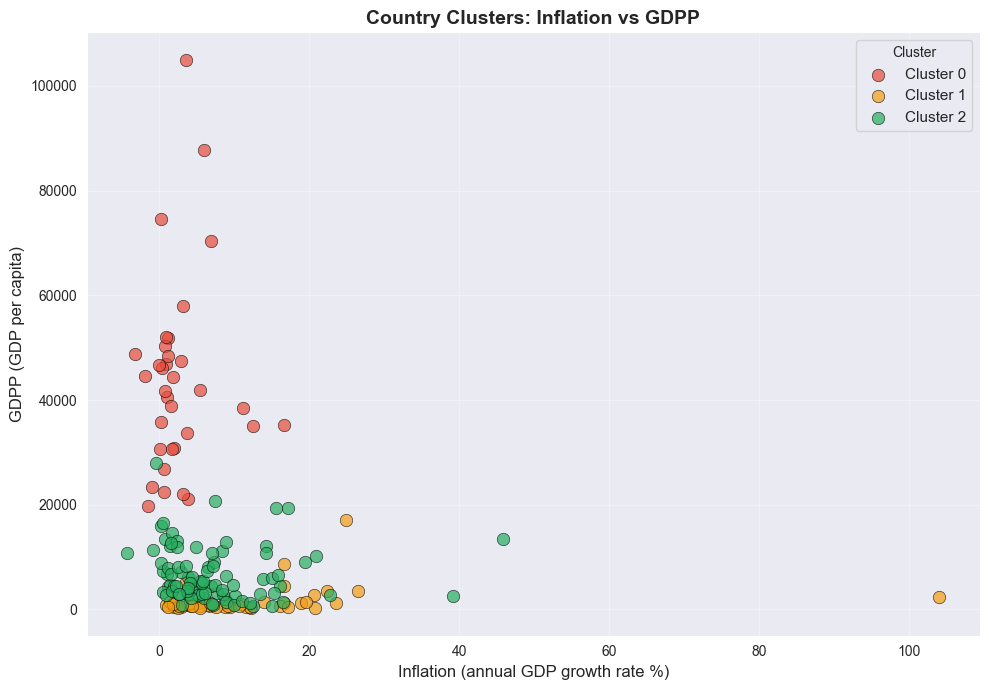

In [21]:
# Visualisation of clusters: inflation vs gdpp
plt.figure(figsize=(10, 7))

for i in range(optimal_k):
    cluster_data = df[df['cluster'] == i]
    plt.scatter(cluster_data['inflation'], cluster_data['gdpp'],
                c=cluster_colors[i], label=cluster_labels[i],
                alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

plt.xlabel('Inflation (annual GDP growth rate %)', fontsize=12)
plt.ylabel('GDPP (GDP per capita)', fontsize=12)
plt.title('Country Clusters: Inflation vs GDPP', fontsize=14, fontweight='bold')
plt.legend(title='Cluster', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusions

### Labelling the Country Groups

Based on the cluster characteristics observed in the visualisations above,
the three groups can be labelled as follows:

**Answer here:**

#### Cluster Labels and Justification

| Cluster | Label | Justification |
|:-------:|:------|:--------------|
| **0** | **Developing** | Moderate child mortality (typically 15-50 per 1000), moderate GDPP (~$1,000-$12,000), and moderate inflation. These countries show intermediate development indicators. |
| **1** | **Least Developed** | High child mortality (>50 per 1000), very low GDPP (<$2,000), and often high inflation. These countries face significant socio-economic challenges. |
| **2** | **Developed** | Low child mortality (<15 per 1000), high GDPP (>$20,000), and low/stable inflation. These countries demonstrate strong economic and health outcomes. |

#### Supporting Evidence from the Data

1. **Child Mortality vs GDPP Plot**: This is the most discriminative visualisation.
   - The **green cluster (Developed)** sits in the top-left: low child mortality, high GDPP.
   - The **orange cluster (Least Developed)** sits in the bottom-right: high child mortality, very low GDPP.
   - The **red cluster (Developing)** occupies the middle ground.

2. **Inflation vs GDPP Plot**: Reinforces the classification:
   - Developed countries cluster at low inflation + high GDPP.
   - Least developed countries show higher inflation volatility with minimal GDPP.
   - Developing countries span the intermediate range.

3. **Alignment with Established Frameworks**: The three-cluster solution aligns with
   the UN's classification system (Least Developed Countries, Developing Countries,
   and Developed Countries) and the World Bank's income groupings (Low, Middle, High income).

#### Why K=3 is Appropriate

- **Elbow Method**: The inertia curve flattens noticeably after K=3, indicating
  diminishing returns from additional clusters.
- **Silhouette Score**: K=3 maintains a strong silhouette score while providing
  interpretable, real-world meaningful groups.
- **Domain Knowledge**: Three development tiers are the standard framework used
  by international organisations (UN, World Bank, IMF) for country classification.